In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("customer_feedback_data.csv")

In [ ]:
print(df.head(10))

       Date Region Customer ID  Satisfaction Score  Feedback Length  \
0   1/31/22  North    CUST1000                67.0             35.0   
1   2/28/22   East    CUST1001                74.0            441.0   
2   3/31/22  North    CUST1002                81.0            127.0   
3   4/30/22   West    CUST1003                 NaN            429.0   
4   5/31/22   West    CUST1004                68.0             43.0   
5   6/30/22  South    CUST1005                62.0            228.0   
6   7/31/22  North    CUST1006                60.0            204.0   
7   8/31/22  North    CUST1007                77.0             78.0   
8   9/30/22   East    CUST1008                69.0            406.0   
9  10/31/22  South    CUST1009                86.0            154.0   

  Issue Resolved  
0            Yes  
1             No  
2            Yes  
3            Yes  
4             No  
5            Yes  
6            Yes  
7            Yes  
8            Yes  
9            Yes  


# Missing Values

In [ ]:
df.isna().sum()

Date                  0
Region                0
Customer ID           0
Satisfaction Score    3
Feedback Length       5
Issue Resolved        0
dtype: int64

# Percentage for Missing Values

In [ ]:
df.isna().mean() * 100

Date                  0.000000
Region                0.000000
Customer ID           0.000000
Satisfaction Score    1.000000
Feedback Length       1.666667
Issue Resolved        0.000000
dtype: float64

# Rows that contain any missing values

In [ ]:
df[df.isna().any(axis = 1)]

,Date,Region,Customer ID,Satisfaction Score,Feedback Length,Issue Resolved
3,4/30/22,West,CUST1003,NaN,429.0,Yes
13,2/28/23,North,CUST1013,93.0,NaN,Yes
40,5/31/25,East,CUST1040,82.0,NaN,No
73,2/29/28,North,CUST1073,NaN,237.0,No
86,3/31/29,East,CUST1086,63.0,NaN,No
117,10/31/31,South,CUST1117,100.0,NaN,No
217,2/29/40,West,CUST1217,NaN,91.0,No
232,5/31/41,South,CUST1232,74.0,NaN,No


In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
295    False
296    False
297    False
298    False
299    False
Length: 300, dtype: bool

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

Date                   object
Region                 object
Customer ID            object
Satisfaction Score    float64
Feedback Length       float64
Issue Resolved         object
dtype: object

In [ ]:
df = pd.read_csv("customer_feedback_data.csv")
print(df.columns)

Index(['Date', 'Region', 'Customer ID', 'Satisfaction Score',
       'Feedback Length', 'Issue Resolved'],
      dtype='object')


# Check for Outliers

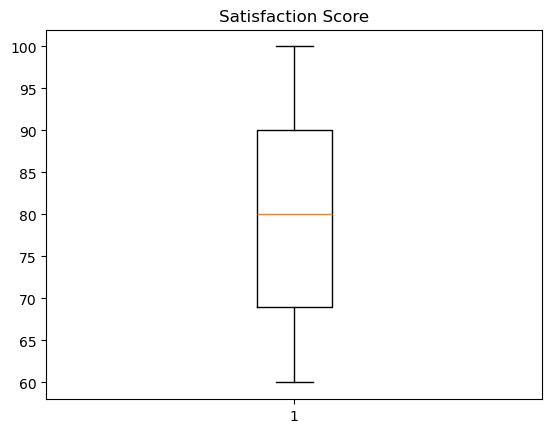

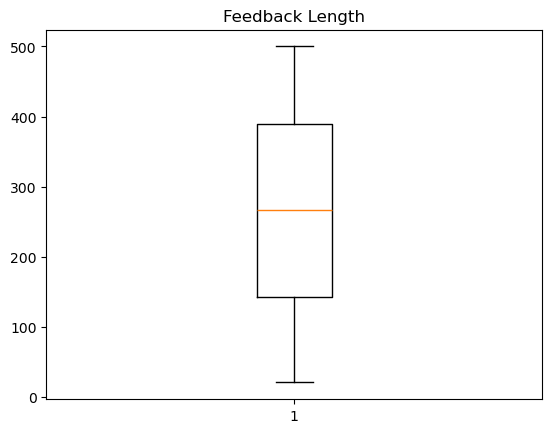

In [ ]:
plt.boxplot(df['Satisfaction Score'].dropna())
plt.title('Satisfaction Score')
plt.show()

plt.boxplot(df['Feedback Length'].dropna())
plt.title('Feedback Length')
plt.show()

There are no strong outliers in Satisfaction scores and no extreme outliers in Feedback Length, but there is high variability. The absence of extreme outliers suggests the database is relatively stable and not heavily influenced by extreme values.

# Descriptive Statistics

In [ ]:
df[['Satisfaction Score', 'Feedback Length']].agg(['mean', 'median', 'std'])

,Satisfaction Score,Feedback Length
mean,79.400673,264.149153
median,80.000000,267.000000
std,12.035887,139.324750


In [ ]:
df.groupby('Region')[['Satisfaction Score', 'Feedback Length']].agg(['mean', 'median', 'std'])

Satisfaction Score                   Feedback Length                   
                     mean median        std            mean median         std
Region                                                                        
East            79.185714   79.5  11.488233      264.147059  296.0  136.309160
North           79.972973   80.0  12.238467      258.959459  242.5  130.213569
South           78.827160   79.0  12.884865      276.417722  282.0  140.981596
West            79.666667   81.0  11.566099      256.243243  244.0  150.592238

In [ ]:
from scipy.stats import ttest_ind
resolved = df[df['Issue Resolved'] == 'Yes']['Satisfaction Score']
not_resolved = df[df['Issue Resolved'] == 'No']['Satisfaction Score']

ttest_ind(resolved, not_resolved)

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [ ]:
df['Issue Resolved'].value_counts()

Issue Resolved
No     157
Yes    143
Name: count, dtype: int64

In [ ]:
from scipy.stats import ttest_ind

resolved = df[df['Issue Resolved'] == 'Yes']['Satisfaction Score'].dropna()
not_resolved = df[df['Issue Resolved'] == 'No']['Satisfaction Score'].dropna()

ttest_ind(resolved, not_resolved)

TtestResult(statistic=np.float64(-2.0660534414665483), pvalue=np.float64(0.03969624434900546), df=np.float64(295.0))

t = -2.066
p = 0.0397

p-value < 0.05 → statistically significant

Satisfaction is LOWER in the "Yes" group compared to "No"
Customers with resolved issues have lower satisfaction than customers with resolved issues.

In [ ]:
import statsmodels.api as sm

# Drop rows where either column has missing values
df_clean = df[['Feedback Length', 'Satisfaction Score']].dropna()

X = df_clean[['Feedback Length']]
y = df_clean['Satisfaction Score']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Satisfaction Score   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.256
Date:                Thu, 26 Mar 2026   Prob (F-statistic):              0.134
Time:                        13:33:03   Log-Likelihood:                -1138.5
No. Observations:                 292   AIC:                             2281.
Df Residuals:                     290   BIC:                             2288.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              81.3506      1.506     

The t-test results show a statistically significant difference in satisfaction scores between customers whose issues were resolved and those whose issues were not resolved (p = 0.0397). Since the p-value is less than 0.05, the difference is considered meaningful. The negative t-statistic indicates that satisfaction scores were slightly lower for customers whose issues were resolved compared to those whose issues were not resolved.


The regression analysis shows that feedback length has a very weak relationship with satisfaction score (R² = 0.008). The coefficient for feedback length is negative, suggesting that longer feedback may be associated with slightly lower satisfaction. However, the p-value (0.134) is greater than 0.05, indicating that this relationship is not statistically significant. Therefore, feedback length does not have a meaningful impact on customer satisfaction in this dataset.

# Satisfaction Score by Issue Resolution Status

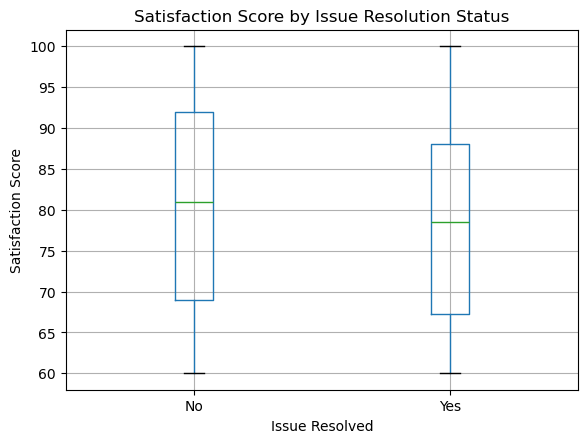

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column='Satisfaction Score', by='Issue Resolved')
plt.title('Satisfaction Score by Issue Resolution Status')
plt.suptitle('')
plt.xlabel('Issue Resolved')
plt.ylabel('Satisfaction Score')
plt.show()

Yes (resolved)is lower in the middle (median) than No. Even when issues are resolved satisfaction is not higher.

In [ ]:
df.groupby('Issue Resolved')['Feedback Length'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
Issue Resolved,,,,
No,267.575163,264.0,141.883695,153
Yes,260.457746,270.5,136.919173,142


#

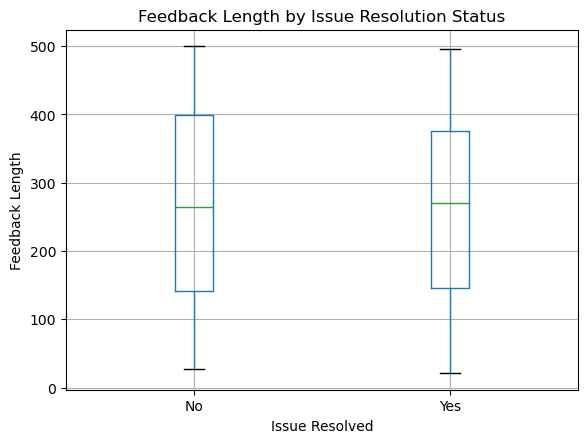

In [ ]:
df.boxplot(column='Feedback Length', by='Issue Resolved')
plt.title('Feedback Length by Issue Resolution Status')
plt.suptitle('')
plt.xlabel('Issue Resolved')
plt.ylabel('Feedback Length')
plt.show()

this boxplot shows almost identical distributions, feedback length does not explain satisfaction differences. This matches regression analysis.

# Resolved-only Regional Analysis

In [ ]:
resolved_only = df[df['Issue Resolved'] == 'Yes']
resolved_only.groupby('Region')['Satisfaction Score'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
Region,,,,
East,78.657895,80.0,11.189465,38
North,78.257143,80.0,12.721780,35
South,76.571429,74.0,11.446257,35
West,78.058824,79.0,11.502150,34
